# **Exploratory Data Analysis** (EDA)



## EDA Workflow

### Systematic Approach

1. **Load and Inspect** - First look at your data
2. **Understand Structure** - Shape, types, missing values
3. **Univariate Analysis** - Individual variables
4. **Bivariate Analysis** - Relationships between pairs
5. **Multivariate Analysis** - Complex relationships
6. **Data Quality** - Check for issues
7. **Summary and Insights** - Document findings

---

## Understanding Your Data

### Initial Inspection


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import missingno as msno


%matplotlib inline
# render higher resolution images :
plt.style.use('seaborn-v0_8')  # or 'default', 'ggplot', etc.
sns.set_style("whitegrid")

In [2]:

# Load data

df = pd.read_csv('Cleaned_airbnb.csv',index_col='Unnamed: 0')




##  `The Dataset` :
>The dataset to be used in this example is a CSV file named **`airbnb.csv`**, which contains data on **airbnb** listings in the state of New York. It contains the following columns:
>- **`listing_id`** : The unique identifier for a listing
>- **`description`** : The description used on the listing
>- **`host_id`** : Unique identifier for a host
>- **`host_name`** : Name of host
>- **`neighbourhood_full`** : Name of boroughs and neighbourhoods
>- **`coordinates`** : Coordinates of listing _(latitude, longitude)_
>- **`Listing added`** : Date of added listing
>- **`room_type`** : Type of room 
>- **`rating`** : Rating from 0 to 5.
>- **`price`** : Price per night for listing
>- **`number_of_reviews`** : Amount of reviews received 
>- **`last_review`** : Date of last review
>- **`reviews_per_month`** : Number of reviews per month
>- **`availability_365`** : Number of days available per year
>- **`Number of stays`** : Total number of stays thus far


In [3]:
# First look


print("Dataset Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nFirst 5 rows:")
print(df.head())
print("\nLast 5 rows:")
print(df.tail())
print("\nRandom 5 rows:")
df.sample(5)


Dataset Shape: (9996, 19)

Column Names: ['listing_id', '5_stars', 'availability_365', 'borough', 'host_id', 'host_name', 'is_rated', 'last_review', 'latitude', 'longitude', 'name', 'neighbourhood', 'number_of_reviews', 'number_of_stays', 'reviews_per_month', 'room_type', 'price', 'rating', 'listing_added']

Data Types:
 listing_id             int64
5_stars              float64
availability_365       int64
borough               object
host_id                int64
host_name             object
is_rated               int64
last_review           object
latitude             float64
longitude            float64
name                  object
neighbourhood         object
number_of_reviews      int64
number_of_stays      float64
reviews_per_month    float64
room_type             object
price                float64
rating               float64
listing_added         object
dtype: object

First 5 rows:
   listing_id   5_stars  availability_365    borough  host_id  \
0        3831  0.757366         

,listing_id,5_stars,availability_365,borough,host_id,host_name,is_rated,last_review,latitude,longitude,name,neighbourhood,number_of_reviews,number_of_stays,reviews_per_month,room_type,price,rating,listing_added
4407,17842111,0.775973,86,Bronx,122044895,Yerddy,1,2019-06-22,40.87810,-73.89998,1st flr full studio apartment- entire place/SAFE,Kingsbridge,116,139.2,4.35,Entire place,99.0,4.246113,2018-12-17
3414,13578642,0.684418,285,Manhattan,10737943,David,1,2018-08-31,40.77989,-73.94763,Medium size room in great location (88th & York),Upper East Side,6,7.2,0.17,Private Room,49.0,4.286289,2018-02-25
9435,35185876,0.000000,228,Manhattan,205909,Nikki,0,NaN,40.74042,-73.99883,PRIME Chelsea Modern Luxury Home *****,Chelsea,0,0.0,0.00,Entire place,225.0,NaN,2018-04-20
7651,29879394,0.707953,250,Brooklyn,14349735,Laurie,1,2018-11-24,40.68683,-73.96572,Clinton Hill - Peaceful and bright room,Clinton Hill,2,2.4,0.25,Private Room,64.0,3.387133,2018-05-21
6496,25153614,0.640446,364,Brooklyn,188391102,Alliot,1,2018-08-29,40.67431,-73.94065,The Crown Master,Crown Heights,2,2.4,0.15,Entire place,150.0,3.373981,2018-02-23


- **`Last_review`** Should be In DateTime Format
- **9996** observation and **16** Columns
- **Price**  and **Rating** Columns Should be in numeric


In [4]:
#converting last review into datetime format
df['last_review']= pd.to_datetime(df['last_review'],format="%Y-%m-%d")
df['last_review']

0      2019-07-05
1      2019-06-29
2      2019-07-01
3      2019-06-22
4      2018-09-30
          ...    
9991          NaT
9992          NaT
9993          NaT
9994          NaT
9995          NaT
Name: last_review, Length: 9996, dtype: datetime64[ns]

In [24]:
# 2. Force the data types back into numeric floats
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
df['price'] = pd.to_numeric(df['price'], errors='coerce')

### Basic Information


In [6]:
# Comprehensive info
df.info()
df.dtypes.count()


<class 'pandas.core.frame.DataFrame'>
Index: 9996 entries, 0 to 9995
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   listing_id         9996 non-null   int64         
 1   5_stars            9996 non-null   float64       
 2   availability_365   9996 non-null   int64         
 3   borough            9996 non-null   object        
 4   host_id            9996 non-null   int64         
 5   host_name          9994 non-null   object        
 6   is_rated           9996 non-null   int64         
 7   last_review        7925 non-null   datetime64[ns]
 8   latitude           9996 non-null   float64       
 9   longitude          9996 non-null   float64       
 10  name               9991 non-null   object        
 11  neighbourhood      9996 non-null   object        
 12  number_of_reviews  9996 non-null   int64         
 13  number_of_stays    9996 non-null   float64       
 14  reviews_per_m

np.int64(19)

- 1 Date-Time column
- 12 Nummerucal Columns
- 5 categorical columns


In [7]:
df.describe()

,listing_id,5_stars,availability_365,host_id,is_rated,last_review,latitude,longitude,number_of_reviews,number_of_stays,reviews_per_month,price,rating
count,9.996000e+03,9996.000000,9996.000000,9.996000e+03,9996.000000,7925,9996.000000,9996.000000,9996.000000,9996.000000,9996.000000,9989.000000,7925.000000
mean,1.926795e+07,0.569658,112.313325,6.798242e+07,0.792817,2018-10-06 19:37:04.504731904,40.729141,-73.951895,22.473089,26.967707,1.074015,149.723446,4.013787
min,3.831000e+03,0.000000,0.000000,2.787000e+03,0.000000,2011-03-28 00:00:00,40.508680,-74.239860,0.000000,0.000000,0.000000,0.000000,3.000633
25%,9.667862e+06,0.611654,0.000000,7.907436e+06,1.000000,2018-07-16 00:00:00,40.689878,-73.982843,1.000000,1.200000,0.040000,70.000000,3.519684
50%,2.005682e+07,0.681852,44.000000,3.165520e+07,1.000000,2019-05-19 00:00:00,40.723040,-73.955405,5.000000,6.000000,0.370000,105.000000,4.027820
75%,2.930811e+07,0.750020,226.000000,1.074344e+08,1.000000,2019-06-23 00:00:00,40.763433,-73.935982,22.000000,26.400000,1.550000,175.000000,4.514542
max,3.648724e+07,0.939950,365.000000,2.741034e+08,1.000000,2019-07-08 00:00:00,40.913060,-73.719280,510.000000,612.000000,16.220000,8000.000000,4.999561
std,1.094710e+07,0.299790,131.650795,7.862972e+07,0.405308,NaN,0.054656,0.045913,43.194466,51.833359,1.540630,202.508709,0.574720


### Missing Values Analysis


- last_review   **20.71%**
- rating           **20.71%**
- price           **0.07%**
- name             **0.05%**
- host_name      **0.02%**

In [8]:
missing = df.isna().sum()
missing_percentage = missing * 100/ len(df)
missing_df = pd.DataFrame(
    {
        "missing" : missing,
        "missing_percent": missing_percentage
    }
)

missing_df= missing_df[missing_df['missing']>0].sort_values(by='missing',ascending=False)
missing_df

,missing,missing_percent
last_review,2071,20.718287
rating,2071,20.718287
price,7,0.070028
name,5,0.050020
host_name,2,0.020008


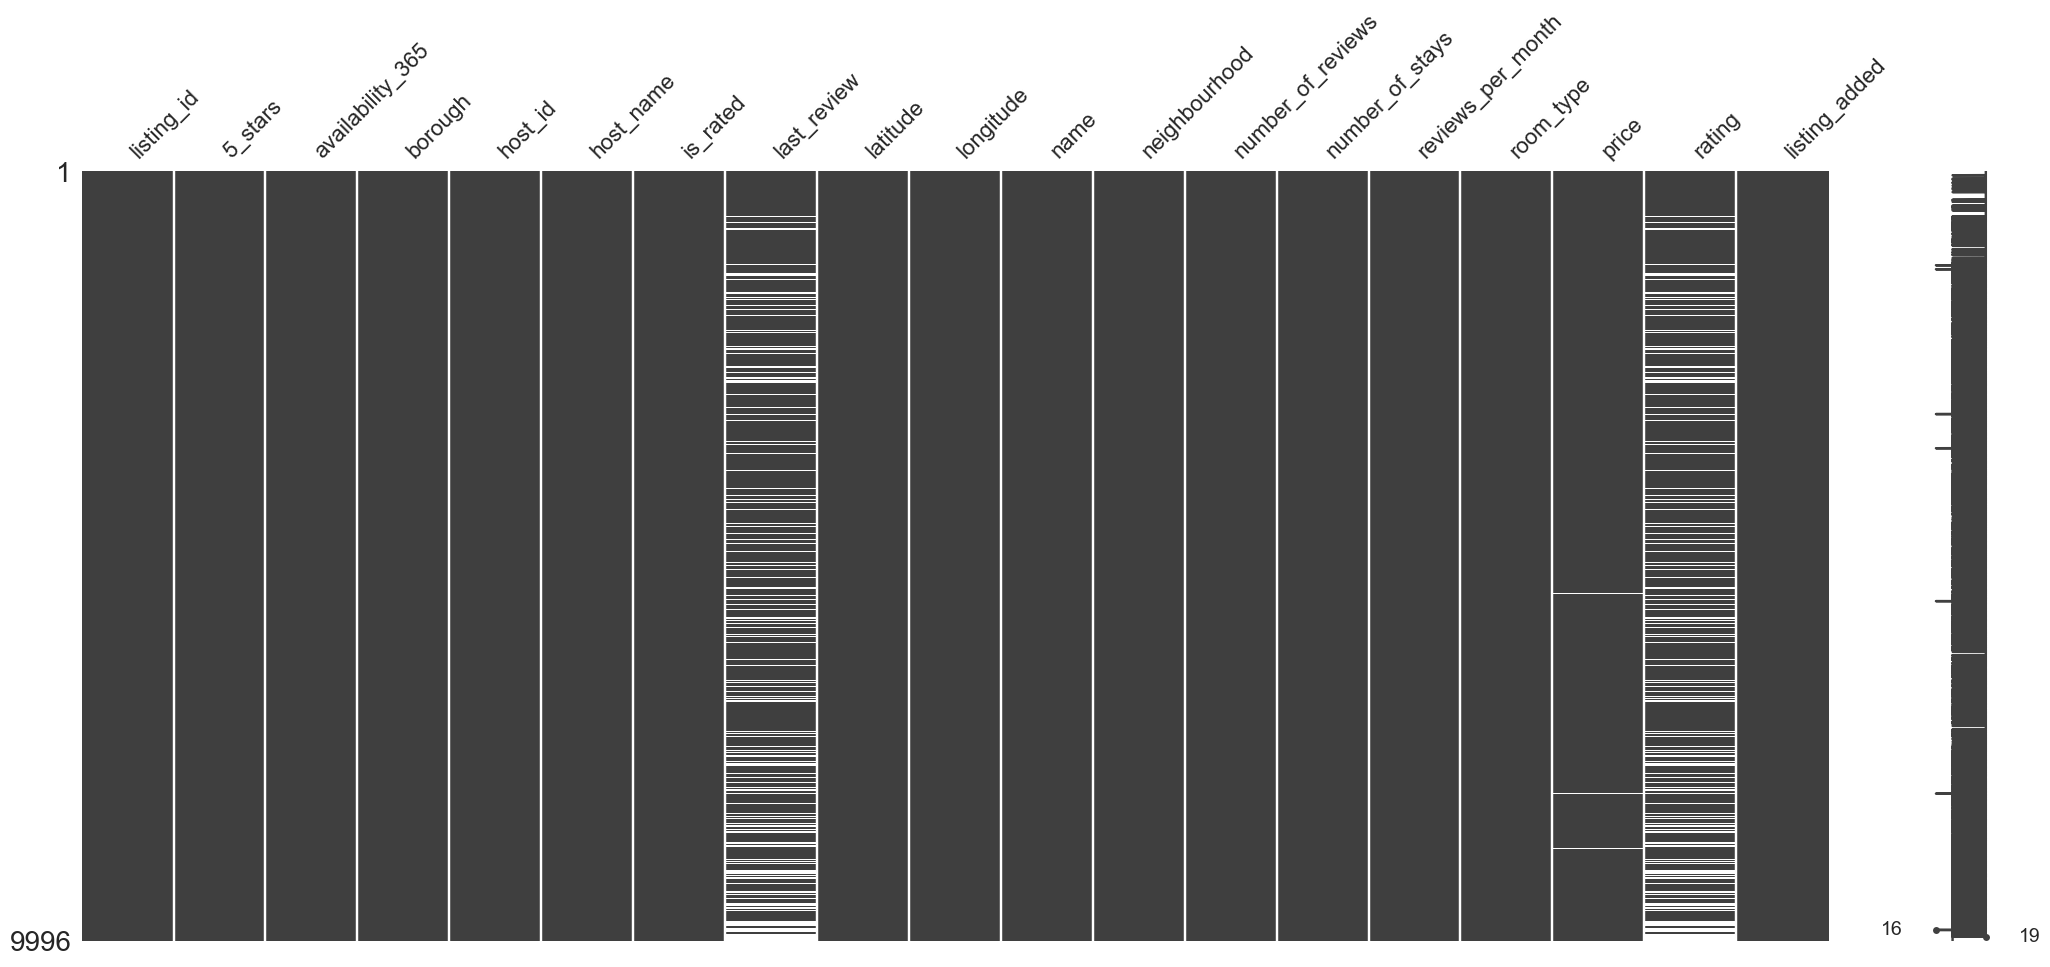

In [9]:
# Visualize missing values
msno.matrix(df)
plt.show()

- **Last Reveiw** and **rating** columns has so much missing value.

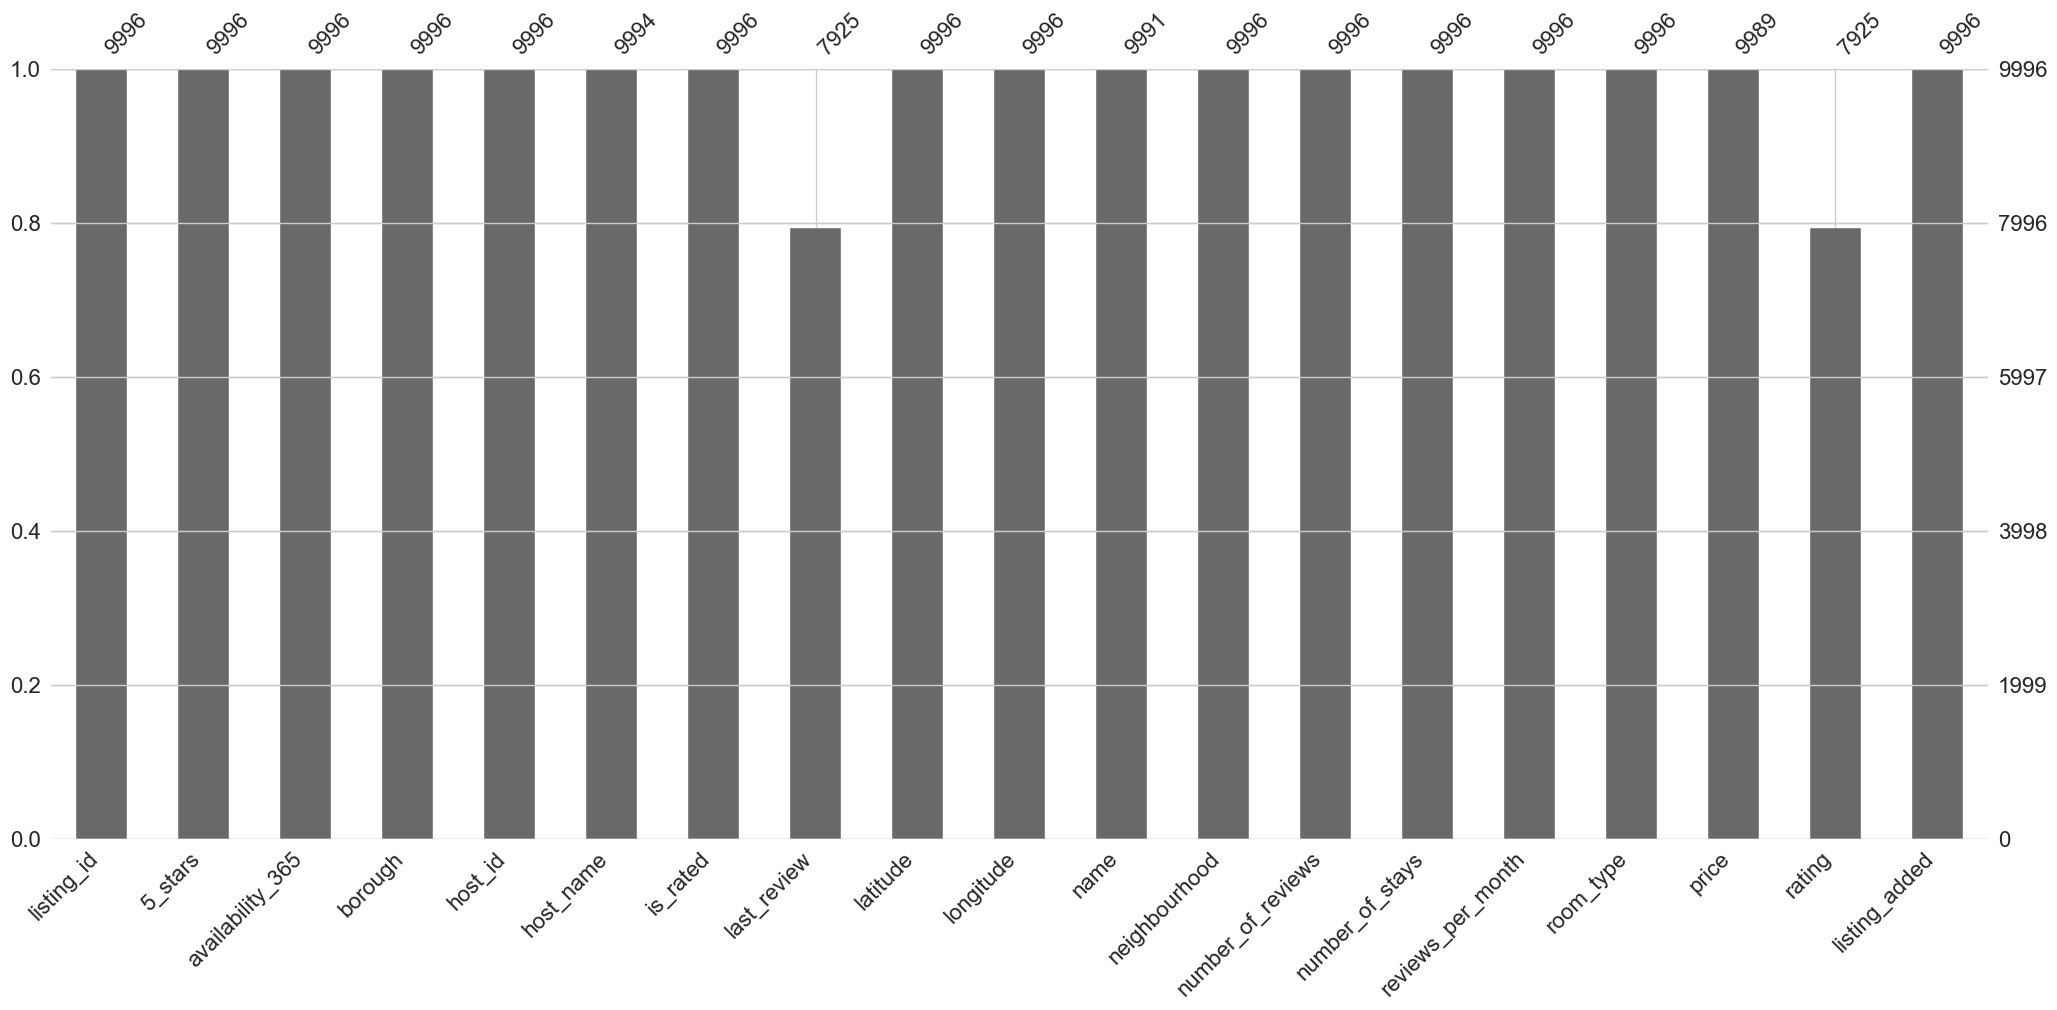

In [10]:

msno.bar(df)
plt.show()

 >- ## Handling missing value

 1. Used **forward fill** for handling last review value missing col
 2. Handling **rating** col missing value 
     - Showing Distribution 1st
     - using **median**
 3. Handling **rating** col missing value 
     - amount -low 
     - using **median**
 4. Droping **Name** and **Host_name**
     - reason - low amount 


In [11]:
# distribution of rating col
fig = px.histogram(df['rating'], title="Distribution of rating column", nbins=50)


fig.update_traces(
    marker_line_width=1.2,       
    marker_line_color="black"   
)

fig.show()

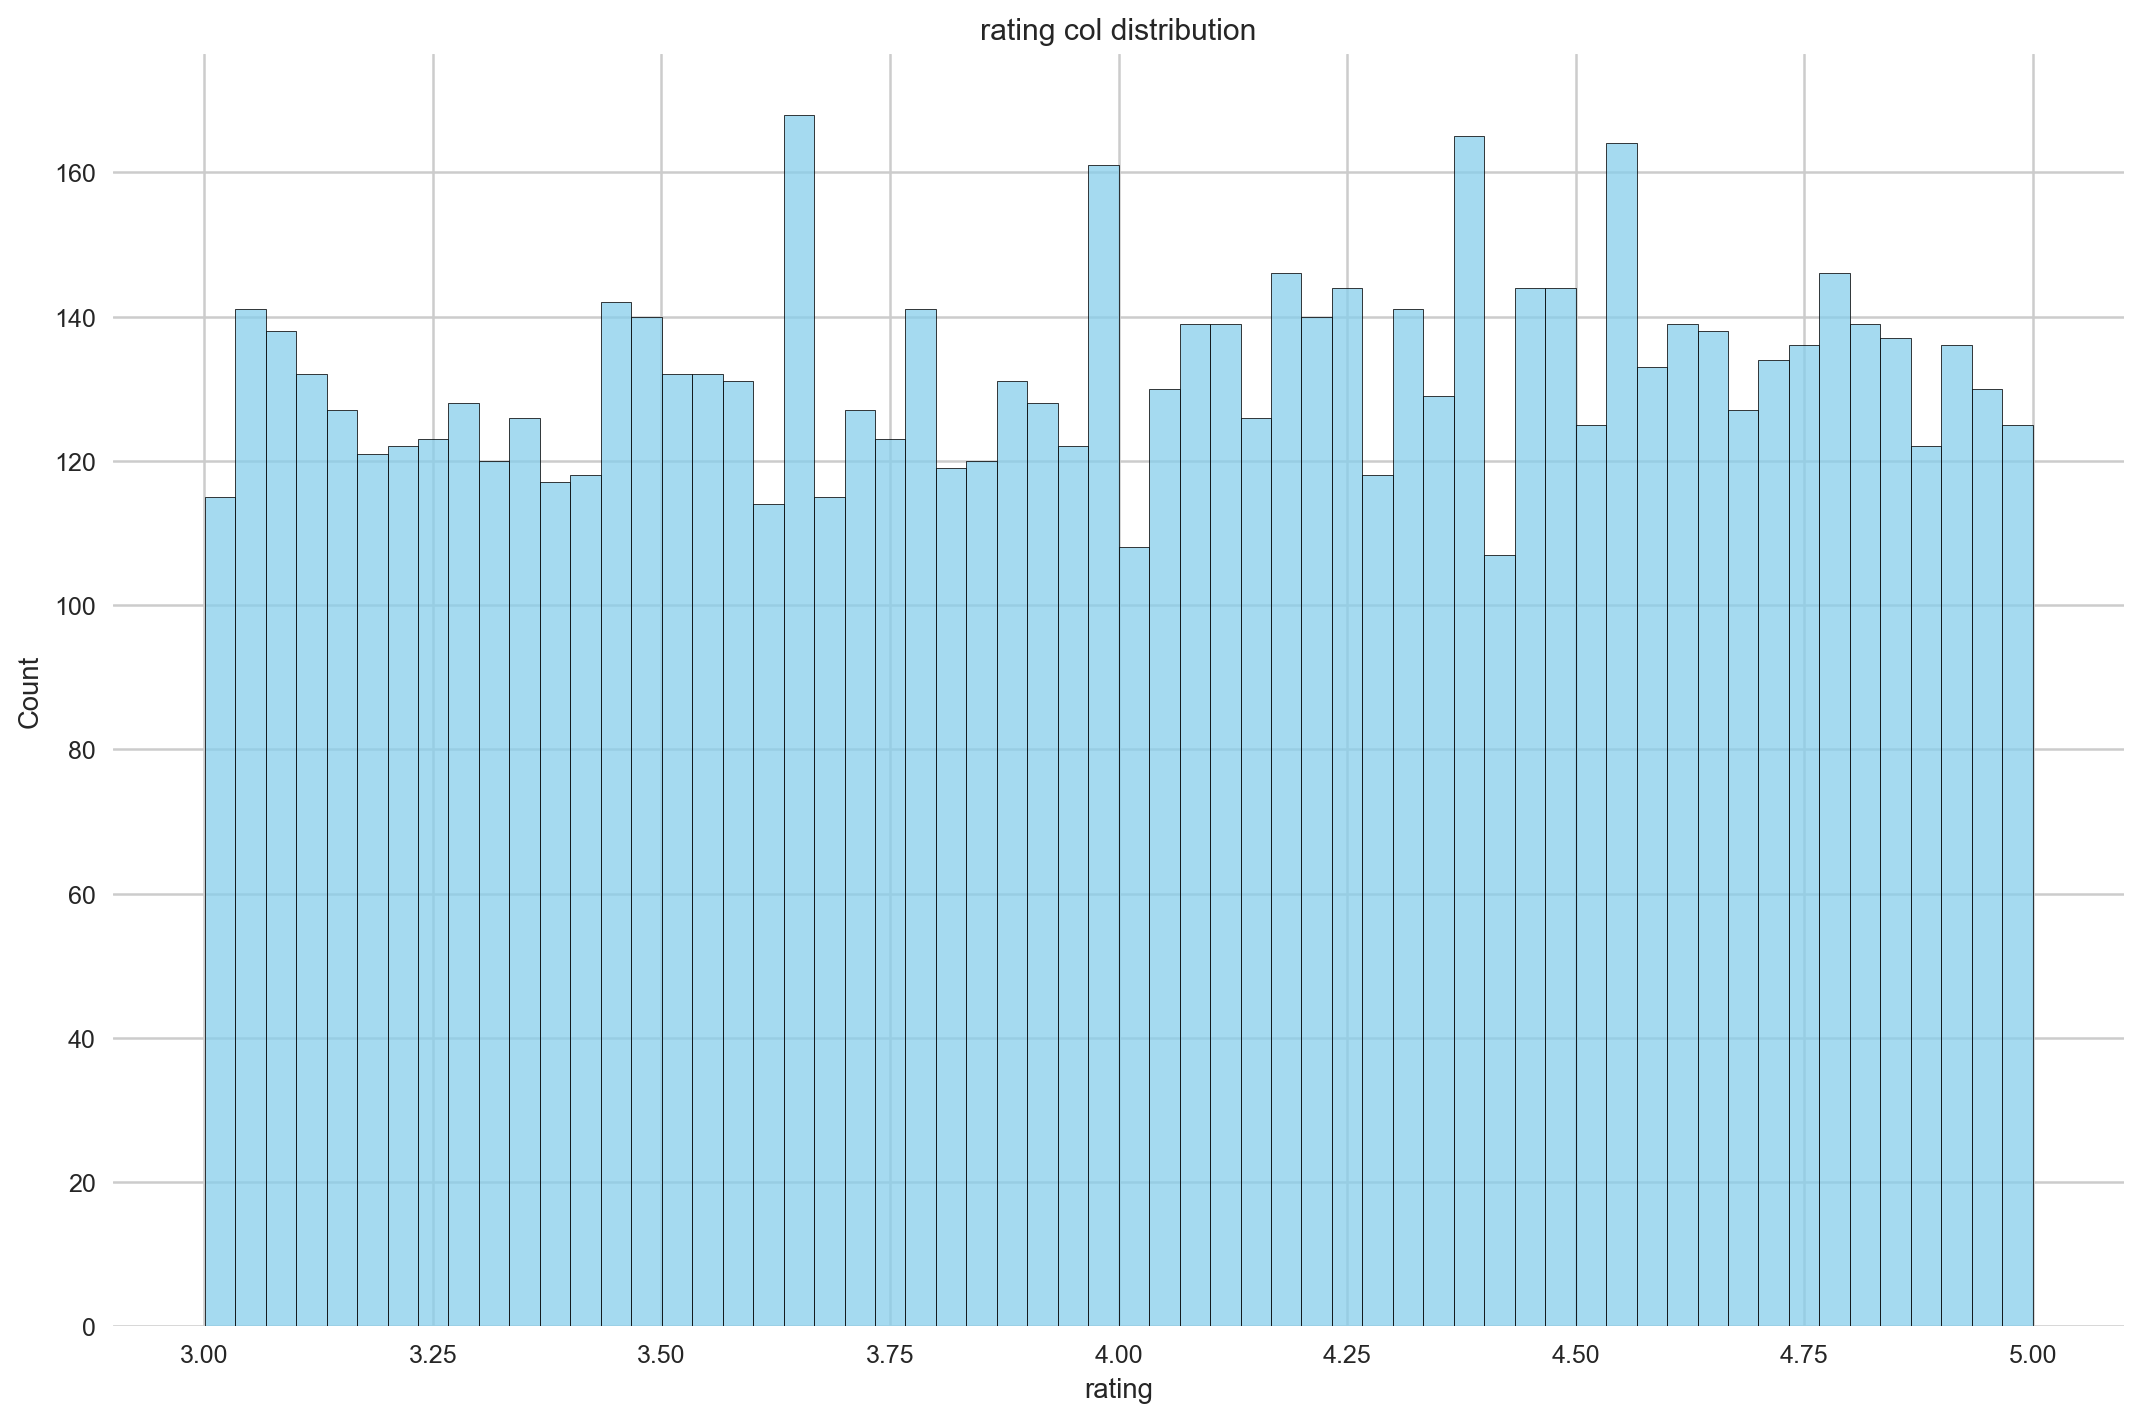

In [12]:
plt.figure(figsize=(12,8) , dpi=180)
sns.histplot(df['rating'] , bins=60 , color='skyblue' , edgecolor='black')
plt.title("rating col distribution")
plt.tight_layout()
plt.show()

In [13]:
# Handling missing col


df['last_review'] =df['last_review'].ffill()
df['rating'].fillna(df['rating'].median , inplace=True)
df['rating'].fillna(df['rating'].median , inplace=True)
df['price'].fillna(df['price'].median , inplace=True)
df = df.dropna(subset=['name', 'host_name'])

C:\Users\PL\AppData\Local\Temp\ipykernel_11312\2902357225.py:5: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '<bound method Series.median of 0       3.273935
1       3.495760
2       4.389051
3       3.305382
4       4.568745
          ...   
9991         NaN
9992         NaN
9993         NaN
9994         NaN
9995         NaN
Name: rating, Length: 9996, dtype: float64>' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.

C:\Users\PL\AppData\Local\Temp\ipykernel_11312\2902357225.py:7: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '<bound method Series.median of 0        89.0
1       140.0
2       140.0
3        99.0
4       120.0
        ...  
9991     42.0
9992     70.0
9993     40.0
9994    115.0
9995     90.0
Name: price, Length: 9996, dtype: float64>' has dtype incompatible with fl

In [14]:
df.isna().sum()

listing_id           0
5_stars              0
availability_365     0
borough              0
host_id              0
host_name            0
is_rated             0
last_review          0
latitude             0
longitude            0
name                 0
neighbourhood        0
number_of_reviews    0
number_of_stays      0
reviews_per_month    0
room_type            0
price                0
rating               0
listing_added        0
dtype: int64

- `No missing value`

### Duplicate Analysis


- **0** Duplicate

In [15]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicates}")

if duplicates > 0:
    print("\nDuplicate rows:")
    print(df[df.duplicated(keep=False)])
    
    # Remove duplicates
    df_clean = df.drop_duplicates()
    print(f"\nAfter removing duplicates: {df_clean.shape}")


Number of duplicate rows: 0


---

## Univariate Analysis

### Numerical Variables


1. > Availability
    - Highly **Right Skewed**
    - Standard Deviation is too high **131**
    - Mean **112**
    - A **Negative Kurtosis**
    - **Outlier** - 0

In [16]:
df['availability_365'].head(4)

0    194
1     46
2     12
3     21
Name: availability_365, dtype: int64

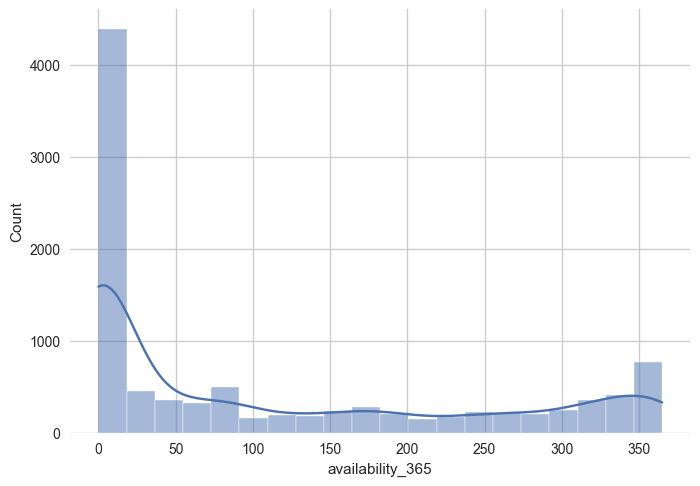

In [17]:
sns.histplot(df['availability_365'] , kde=True,bins=20)

plt.show()

In [18]:
def analyze_numerical(df , column):
    
    print("Basic Statistics")
    print(df[column].describe())

    #descriptive statistics
    
    display(f"Mean : {df[column].mean():.2f}")
    display(f"Median : {df[column].median():.2f}")
    display(f"Mode : {df[column].mode()}")
    display(f"variance : {df[column].var():.2f}")
    display(f"standard deviation : {df[column].std():.2f}")
    display(f"Skewness : {df[column].skew():.2f}")
    display(f"Kurtosis : {df[column].kurtosis():.2f}")
    
    
    #outlier Detection
    
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 -Q1
    
    lower = Q1 - (1.5*IQR)
    upper = Q3 + (1.5*IQR)
    
    outliers = df[(df[column]<lower) | (df[column]>upper)]
    print(outliers)
    
    print(f"Outlier IQR Method { len(outliers)}")
    

In [19]:
analyze_numerical(df, 'availability_365')

Basic Statistics
count    9989.000000
mean      112.355791
std       131.644436
min         0.000000
25%         0.000000
50%        44.000000
75%       226.000000
max       365.000000
Name: availability_365, dtype: float64


'Mean : 112.36'

'Median : 44.00'

'Mode : 0    0\nName: availability_365, dtype: int64'

'variance : 17330.26'

'standard deviation : 131.64'

'Skewness : 0.77'

'Kurtosis : -0.99'

Empty DataFrame
Columns: [listing_id, 5_stars, availability_365, borough, host_id, host_name, is_rated, last_review, latitude, longitude, name, neighbourhood, number_of_reviews, number_of_stays, reviews_per_month, room_type, price, rating, listing_added]
Index: []
Outlier IQR Method 0


In [20]:
px.box(df['availability_365'] , title="Boxplot")

<Axes: ylabel='availability_365'>

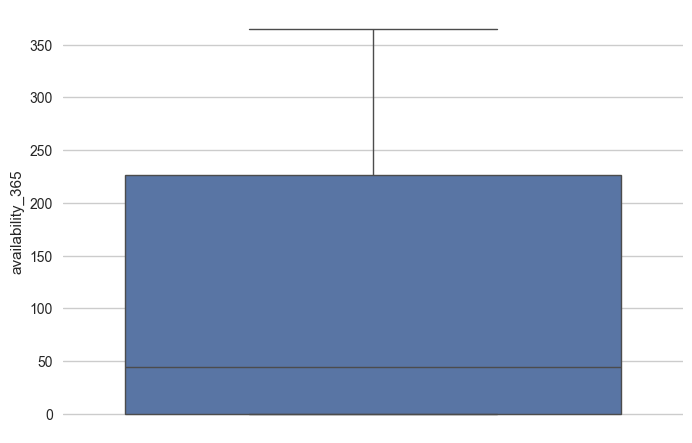

In [21]:
sns.boxplot(df['availability_365'])

2. > Number of review
      - standard deviation : 0.57
      - Skewness : -0.04
      - Kurtosis : -1.19
      - Mean : 4.01
      - Median : 4.03'

In [26]:
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9989 entries, 0 to 9995
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   listing_id         9989 non-null   int64         
 1   5_stars            9989 non-null   float64       
 2   availability_365   9989 non-null   int64         
 3   borough            9989 non-null   object        
 4   host_id            9989 non-null   int64         
 5   host_name          9989 non-null   object        
 6   is_rated           9989 non-null   int64         
 7   last_review        9989 non-null   datetime64[ns]
 8   latitude           9989 non-null   float64       
 9   longitude          9989 non-null   float64       
 10  name               9989 non-null   object        
 11  neighbourhood      9989 non-null   object        
 12  number_of_reviews  9989 non-null   int64         
 13  number_of_stays    9989 non-null   float64       
 14  reviews_per_m

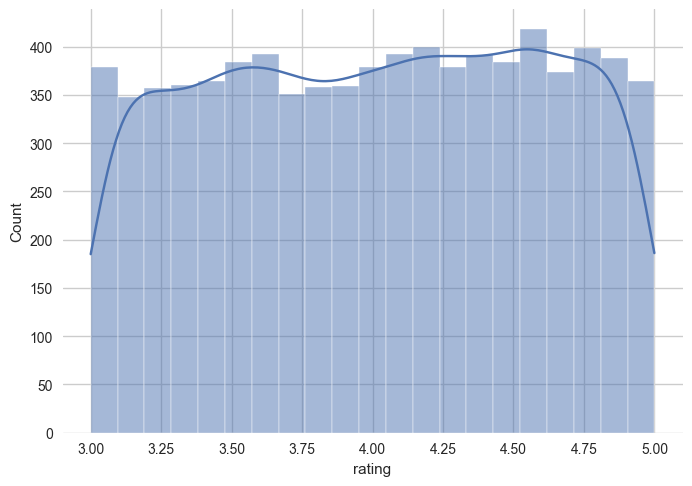

In [27]:


sns.histplot(df['rating'] , kde=True)
plt.show()

In [28]:
analyze_numerical(df , 'rating')

Basic Statistics
count    7923.000000
mean        4.013775
std         0.574665
min         3.000633
25%         3.519718
50%         4.027820
75%         4.514495
max         4.999561
Name: rating, dtype: float64


'Mean : 4.01'

'Median : 4.03'

'Mode : 0       3.000633\n1       3.000692\n2       3.000725\n3       3.000904\n4       3.001921\n          ...   \n7918    4.998753\n7919    4.998890\n7920    4.998898\n7921    4.999229\n7922    4.999561\nName: rating, Length: 7923, dtype: float64'

'variance : 0.33'

'standard deviation : 0.57'

'Skewness : -0.04'

'Kurtosis : -1.19'

Empty DataFrame
Columns: [listing_id, 5_stars, availability_365, borough, host_id, host_name, is_rated, last_review, latitude, longitude, name, neighbourhood, number_of_reviews, number_of_stays, reviews_per_month, room_type, price, rating, listing_added]
Index: []
Outlier IQR Method 0


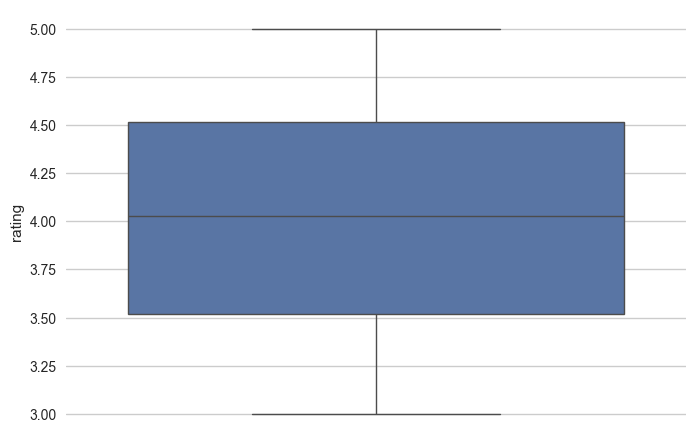

In [29]:
sns.boxplot(df['rating'])
plt.show()

3. >  Price
    - **568** Outlier Exist. Need to Fix Later
    - Mean : 149.75
    - Median : 105.00
    - standard deviation : 202.56
    - Skewness : 14.71
    - Kurtosis : 380.64

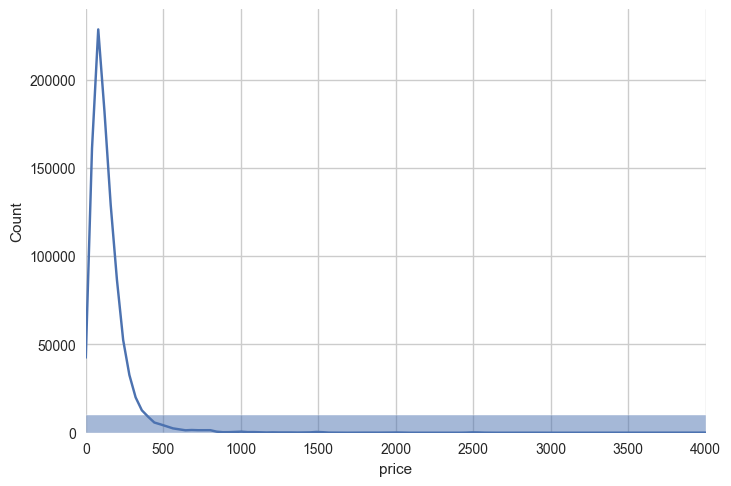

In [30]:
sns.histplot(df['price'] , kde=True ,bins=2)
plt.xlim(0,4000)
plt.show()

In [31]:
analyze_numerical(df , 'price')

Basic Statistics
count    9982.000000
mean      149.747295
std       202.563185
min         0.000000
25%        70.000000
50%       105.000000
75%       175.000000
max      8000.000000
Name: price, dtype: float64


'Mean : 149.75'

'Median : 105.00'

'Mode : 0    150.0\nName: price, dtype: float64'

'variance : 41031.84'

'standard deviation : 202.56'

'Skewness : 14.71'

'Kurtosis : 380.64'

      listing_id   5_stars  availability_365    borough    host_id  \
61         68974  0.701466               298  Manhattan     281229   
62         70609  0.848930               297  Manhattan      72062   
65         80700  0.748050                60   Brooklyn     417504   
81        125053  0.782723               170  Manhattan     622460   
86        141890  0.880402                 0  Manhattan     689661   
...          ...       ...               ...        ...        ...   
9958    36404568  0.000000               307  Manhattan  107434423   
9963    36415840  0.000000               365   Brooklyn  223715460   
9964    36417250  0.000000                 4  Manhattan  133288905   
9967    36420289  0.000000               364     Queens   73211393   
9983    36452721  0.000000                23   Brooklyn  274079964   

                host_name  is_rated last_review  latitude  longitude  \
61                 Alicia         1  2019-06-20  40.71943  -73.99627   
62             

<Axes: ylabel='price'>

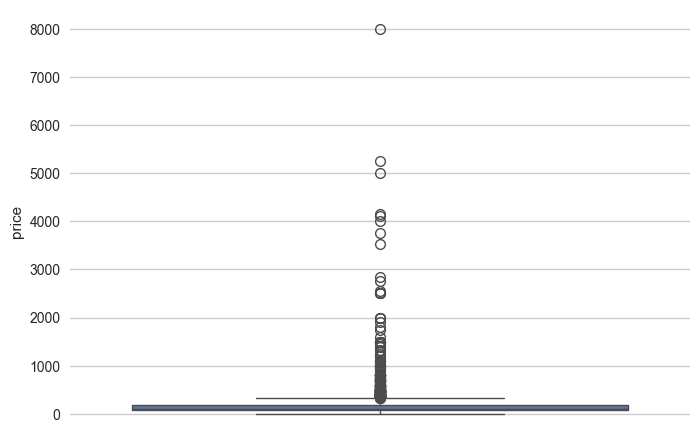

In [32]:
sns.boxplot(df['price'])

> ###  Categorical Variables



1. > Room Type
     - Three Unique room. **Entire place 5171  Private Room 4592
Shared room 226**

In [33]:
def analyze_categorical(df, column):
    """
    Comprehensive analysis of a categorical column
    """
    print(f"Analysis of: {column}")
    
    # Value counts
    value_counts = df[column].value_counts()
    print("\nValue Counts:")
    display(value_counts)
    
    # Percentages
    print("\nPercentages:")
    print(df[column].value_counts(normalize=True) * 100)
    
    # Unique values
    print(f"\nNumber of unique values: {df[column].nunique()}")
    print(f"Unique values: {df[column].unique()}")
    
 

In [34]:
analyze_categorical(df , 'room_type')

Analysis of: room_type

Value Counts:


room_type
Entire place    5171
Private Room    4592
Shared room      226
Name: count, dtype: int64


Percentages:
room_type
Entire place    51.766944
Private Room    45.970568
Shared room      2.262489
Name: proportion, dtype: float64

Number of unique values: 3
Unique values: ['Entire place' 'Private Room' 'Shared room']


In [35]:
df.head(3)

,listing_id,5_stars,availability_365,borough,host_id,host_name,is_rated,last_review,latitude,longitude,name,neighbourhood,number_of_reviews,number_of_stays,reviews_per_month,room_type,price,rating,listing_added
0,3831,0.757366,194,Brooklyn,4869,LisaRoxanne,1,2019-07-05,40.68514,-73.95976,Cozy Entire Floor of Brownstone,Clinton Hill,270,324.0,4.64,Entire place,89.0,3.273935,2018-12-30
1,6848,0.789743,46,Brooklyn,15991,Allen & Irina,1,2019-06-29,40.70837,-73.95352,Only 2 stops to Manhattan studio,Williamsburg,148,177.6,1.20,Entire place,140.0,3.495760,2018-12-24
2,7322,0.669873,12,Manhattan,18946,Doti,1,2019-07-01,40.74192,-73.99501,Chelsea Perfect,Chelsea,260,312.0,2.12,Private Room,140.0,4.389051,2018-12-26


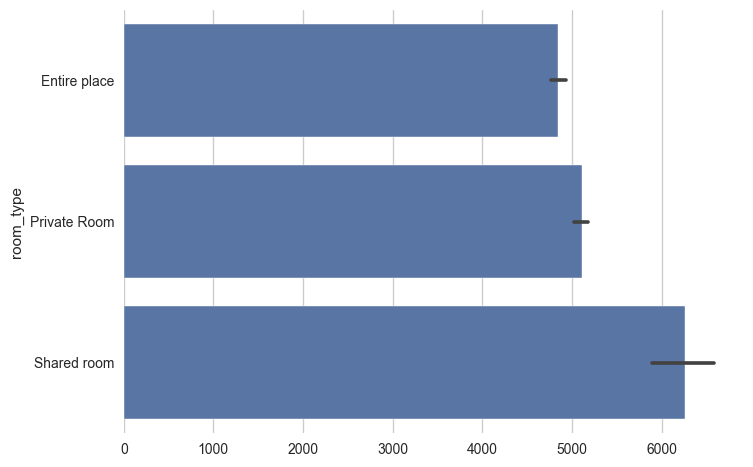

In [36]:
sns.barplot(df['room_type'])
plt.show()

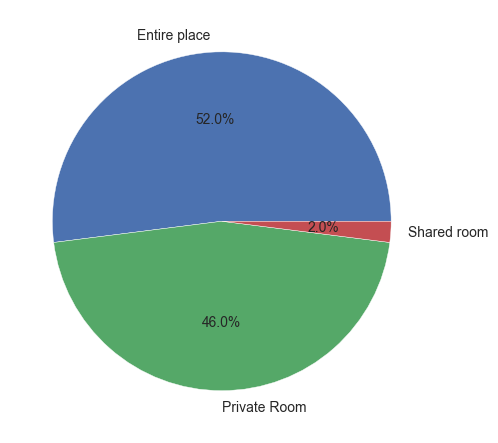

In [37]:
value_count = df['room_type'].value_counts(normalize=True).round(2)

plt.pie(value_count , labels = value_count.index , autopct = "%1.1f%%")
plt.show()

2. > Borough
   
    - 5 unique value
    - Manhattan        4436
    - Brooklyn         4071
    - Queens           1180
    - Bronx             229
    - Staten Island      73
    - **Manhattan , Brooklyn ,Queens are three most Famous area taking 97%** 
    

In [38]:
analyze_categorical(df , 'borough')

Analysis of: borough

Value Counts:


borough
Manhattan        4436
Brooklyn         4071
Queens           1180
Bronx             229
Staten Island      73
Name: count, dtype: int64


Percentages:
borough
Manhattan        44.408850
Brooklyn         40.754830
Queens           11.812994
Bronx             2.292522
Staten Island     0.730804
Name: proportion, dtype: float64

Number of unique values: 5
Unique values: ['Brooklyn' 'Manhattan' 'Bronx' 'Queens' 'Staten Island']


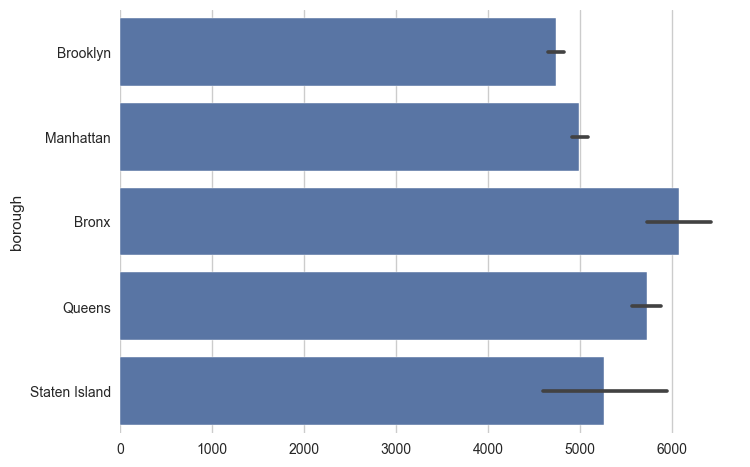

In [39]:
sns.barplot(df['borough'])
plt.show()

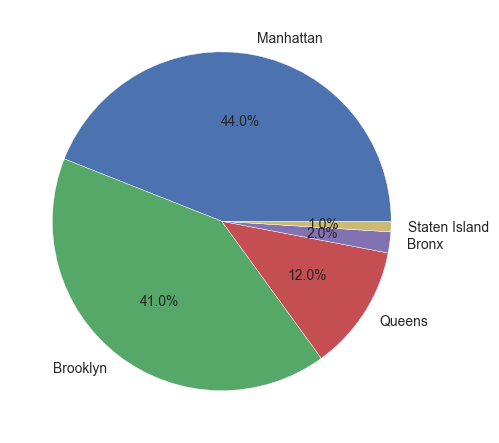

In [40]:
value_count = df['borough'].value_counts(normalize=True).round(2)

plt.pie(value_count , labels = value_count.index , autopct = "%1.1f%%")
plt.show()

---

## Bivariate Analysis

### Numerical vs Numerical



Correlation between rating and price: -0.005


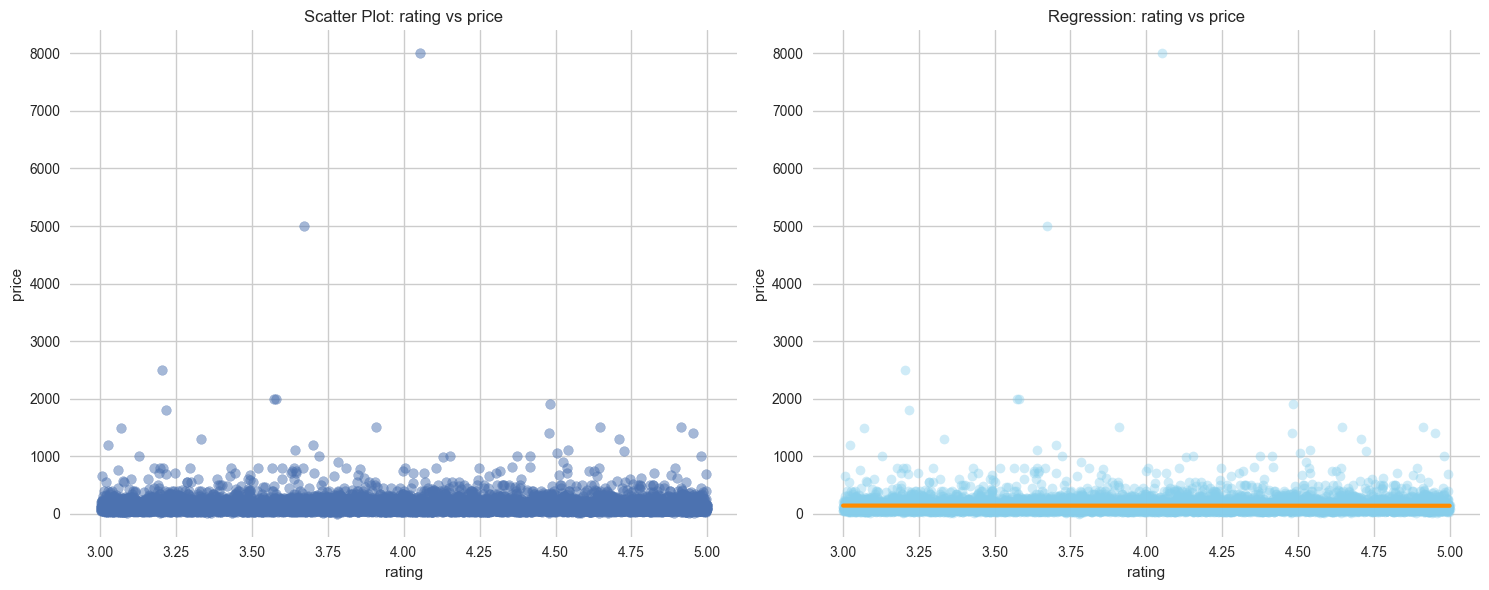


Generating Joint Distribution Plot for rating and price...


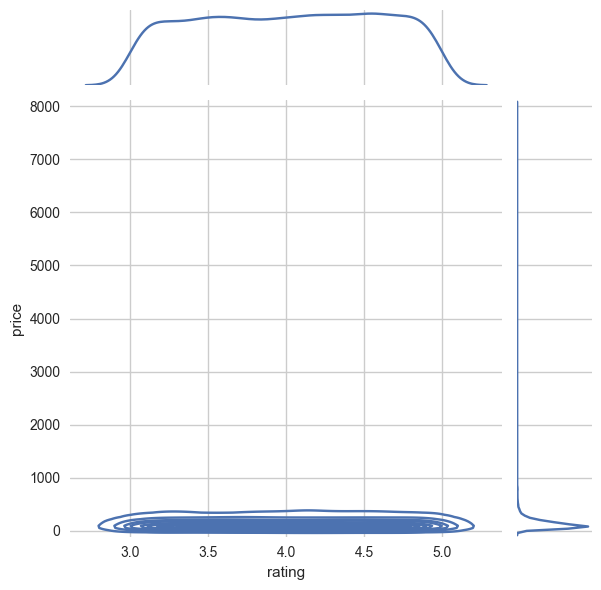

In [47]:
def analyze_numerical_pair(df, col1, col2):
    """
    Analyze relationship between two numerical variables safely
    """

    clean_df = df[[col1, col2]].copy()
    clean_df[col1] = pd.to_numeric(clean_df[col1], errors='coerce')
    clean_df[col2] = pd.to_numeric(clean_df[col2], errors='coerce')
    clean_df = clean_df.dropna()  
    
    # 2. Compute correlation using the CLEAN data
    correlation = clean_df[col1].corr(clean_df[col2])
    print(f"\nCorrelation between {col1} and {col2}: {correlation:.3f}")
    
    # 3. Create subplots (1 row, 2 columns)
    fig, axes = plt.subplots(1, 2, figsize=(15, 6)) # 6 height keeps it proportional
    
    # --- Scatter Plot (Left Side: index 0) ---
    axes[0].scatter(clean_df[col1], clean_df[col2], alpha=0.5) # Using clean_df
    axes[0].set_xlabel(col1)
    axes[0].set_ylabel(col2)
    axes[0].set_title(f'Scatter Plot: {col1} vs {col2}')
    
    # --- Regression Plot (Right Side: index 1) ---
    sns.regplot(
        x=clean_df[col1], 
        y=clean_df[col2], 
        ax=axes[1], 
        scatter_kws={'color': 'skyblue', 'alpha': 0.4},
        line_kws={'color': 'darkorange', 'linewidth': 3}
    )
    axes[1].set_xlabel(col1)
    axes[1].set_ylabel(col2)
    axes[1].set_title(f'Regression: {col1} vs {col2}')
    
    plt.tight_layout()
    plt.show() 
    
    # --- Joinplot (Triggers separately after the main grid closes) ---
    print(f"\nGenerating Joint Distribution Plot for {col1} and {col2}...")
    sns.jointplot(data=clean_df, x=col1, y=col2, kind='kde')
    plt.show()

# Run it
analyze_numerical_pair(df, 'rating', 'price')

### Numerical vs Categorical


In [ ]:
def analyze_numerical_categorical(df, num_col, cat_col):
    """
    Analyze relationship between numerical and categorical variables
    """
    # Group statistics
    print(f"\nStatistics of {num_col} by {cat_col}:")
    print(df.groupby(cat_col)[num_col].describe())
    
    # Visualizations
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Box plot
    df.boxplot(column=num_col, by=cat_col, ax=axes[0, 0])
    axes[0, 0].set_title(f'{num_col} by {cat_col}')
    axes[0, 0].set_xlabel(cat_col)
    axes[0, 0].set_ylabel(num_col)
    
    # Violin plot
    sns.violinplot(data=df, x=cat_col, y=num_col, ax=axes[0, 1])
    axes[0, 1].set_title(f'Violin Plot: {num_col} by {cat_col}')
    
    # Histogram by category
    for category in df[cat_col].unique():
        axes[1, 0].hist(df[df[cat_col]==category][num_col], 
                       alpha=0.5, label=category, bins=20)
    axes[1, 0].set_xlabel(num_col)
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].set_title(f'Distribution of {num_col} by {cat_col}')
    axes[1, 0].legend()
    
    # Bar plot of means
    means = df.groupby(cat_col)[num_col].mean()
    means.plot(kind='bar', ax=axes[1, 1])
    axes[1, 1].set_title(f'Mean {num_col} by {cat_col}')
    axes[1, 1].set_xlabel(cat_col)
    axes[1, 1].set_ylabel(f'Mean {num_col}')
    axes[1, 1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

# Example
analyze_numerical_categorical(df, 'income', 'category')

### Categorical vs Categorical


In [ ]:
def analyze_categorical_pair(df, col1, col2):
    """
    Analyze relationship between two categorical variables
    """
    # Contingency table
    contingency = pd.crosstab(df[col1], df[col2])
    print(f"\nContingency Table: {col1} vs {col2}")
    print(contingency)
    
    # Chi-square test
    from scipy.stats import chi2_contingency
    chi2, p_value, dof, expected = chi2_contingency(contingency)
    print(f"\nChi-square test:")
    print(f"Chi-square statistic: {chi2:.3f}")
    print(f"P-value: {p_value:.3f}")
    print(f"Degrees of freedom: {dof}")
    
    # Visualizations
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Stacked bar chart
    contingency.plot(kind='bar', stacked=True, ax=axes[0])
    axes[0].set_title(f'Stacked Bar Chart: {col1} vs {col2}')
    axes[0].set_xlabel(col1)
    axes[0].set_ylabel('Count')
    axes[0].legend(title=col2)
    axes[0].tick_params(axis='x', rotation=45)
    
    # Heatmap
    sns.heatmap(contingency, annot=True, fmt='d', cmap='Blues', ax=axes[1])
    axes[1].set_title(f'Heatmap: {col1} vs {col2}')
    
    plt.tight_layout()
    plt.show()

# Example
analyze_categorical_pair(df, 'category', 'status')

---

## Multivariate Analysis

### Correlation Matrix


In [ ]:
# Calculate correlation matrix
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()

# Visualize
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', 
            cmap='coolwarm', center=0, square=True, linewidths=1)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

# Find highly correlated pairs
high_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.7:
            high_corr.append((
                correlation_matrix.columns[i],
                correlation_matrix.columns[j],
                correlation_matrix.iloc[i, j]
            ))

print("\nHighly Correlated Pairs (|r| > 0.7):")
for col1, col2, corr in high_corr:
    print(f"{col1} - {col2}: {corr:.3f}")

### Pair Plot


In [ ]:
# Pair plot for key numerical variables
key_vars = ['var1', 'var2', 'var3', 'var4']  # Select key variables
sns.pairplot(df[key_vars], diag_kind='kde')
plt.show()

### Principal Component Analysis (PCA) Visualization


In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Select numerical columns
numeric_df = df.select_dtypes(include=[np.number]).dropna()

# Standardize
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_df)

# Apply PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

# Visualize
plt.figure(figsize=(10, 6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.5)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.title('PCA Visualization')
plt.show()

---

## Data Quality Checks

### Outlier Detection


In [ ]:
def detect_outliers_iqr(df, column):
    """
    Detect outliers using IQR method
    """
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers

def detect_outliers_zscore(df, column, threshold=3):
    """
    Detect outliers using Z-score method
    """
    z_scores = np.abs((df[column] - df[column].mean()) / df[column].std())
    outliers = df[z_scores > threshold]
    return outliers

# Example
outliers_iqr = detect_outliers_iqr(df, 'age')
outliers_zscore = detect_outliers_zscore(df, 'age')
print(f"IQR outliers: {len(outliers_iqr)}")
print(f"Z-score outliers: {len(outliers_zscore)}")

### Data Consistency Checks


In [ ]:
# Check for logical inconsistencies
def check_consistency(df):
    """
    Check for logical inconsistencies in data
    """
    issues = []
    
    # Example: Age should be positive
    if 'age' in df.columns:
        negative_age = df[df['age'] < 0]
        if len(negative_age) > 0:
            issues.append(f"Found {len(negative_age)} rows with negative age")
    
    # Example: Start date should be before end date
    if 'start_date' in df.columns and 'end_date' in df.columns:
        invalid_dates = df[df['start_date'] > df['end_date']]
        if len(invalid_dates) > 0:
            issues.append(f"Found {len(invalid_dates)} rows with start_date > end_date")
    
    return issues

issues = check_consistency(df)
if issues:
    print("Data Consistency Issues:")
    for issue in issues:
        print(f"  - {issue}")
else:
    print("No consistency issues found")

---

## EDA Best Practices

### 1. Start with Questions

Before analyzing, ask:
- What problem are we solving?
- What do we expect to find?
- What questions need answers?

### 2. Document Everything


In [ ]:
# Create EDA report
def create_eda_report(df, output_file='eda_report.txt'):
    """
    Generate comprehensive EDA report
    """
    with open(output_file, 'w') as f:
        f.write("="*50 + "\n")
        f.write("EXPLORATORY DATA ANALYSIS REPORT\n")
        f.write("="*50 + "\n\n")
        
        f.write("1. DATASET OVERVIEW\n")
        f.write(f"   Shape: {df.shape}\n")
        f.write(f"   Columns: {df.columns.tolist()}\n\n")
        
        f.write("2. MISSING VALUES\n")
        missing = df.isnull().sum()
        for col, count in missing[missing > 0].items():
            f.write(f"   {col}: {count} ({100*count/len(df):.2f}%)\n")
        f.write("\n")
        
        f.write("3. DATA TYPES\n")
        for col, dtype in df.dtypes.items():
            f.write(f"   {col}: {dtype}\n")
        f.write("\n")
        
        f.write("4. SUMMARY STATISTICS\n")
        f.write(str(df.describe()))
        f.write("\n\n")
        
        # Add more sections as needed
        
    print(f"EDA report saved to {output_file}")

create_eda_report(df)

### 3. Use Visualizations

- Visuals reveal patterns numbers miss
- Use appropriate plot types
- Keep plots clear and labeled

### 4. Iterate

- EDA is iterative
- New questions arise from initial findings
- Deep dive into interesting patterns

### 5. Validate Assumptions

- Check normality for parametric tests
- Verify independence assumptions
- Test for multicollinearity

---

## Practice Exercises

### Exercise 1: Complete EDA

Perform complete EDA on a dataset:
1. Load and inspect
2. Check missing values
3. Analyze each variable
4. Find relationships
5. Detect outliers
6. Create summary report

### Exercise 2: Hypothesis Testing

Form hypotheses and test them:
- "Older customers spend more"
- "Category A has higher sales"
- "There's a correlation between X and Y"

### Exercise 3: Feature Engineering Ideas

Based on EDA, suggest:
- New features to create
- Features to remove
- Transformations needed

---

## Resources

### Libraries

- **Pandas**: Data manipulation
- **NumPy**: Numerical operations
- **Matplotlib/Seaborn**: Visualization
- **Missingno**: Missing data visualization
- **Scipy**: Statistical tests

### Books

- **"Exploratory Data Analysis"** by John Tukey
- **"Python for Data Analysis"** by Wes McKinney

### Tools

- **Jupyter Notebook**: Interactive EDA
- **Pandas Profiling**: Automated EDA reports


In [ ]:
# Install: pip install pandas-profiling
from pandas_profiling import ProfileReport

profile = ProfileReport(df, title="EDA Report")
profile.to_file("eda_report.html")

---

## Data Storytelling

### What is Data Storytelling?

Data storytelling is the art of communicating insights from data analysis in a clear, compelling, and actionable way. It combines data analysis, visualization, and narrative to help stakeholders understand and act on findings.

### Why Data Storytelling Matters

- **Actionable Insights**: Turns data into decisions
- **Stakeholder Engagement**: Keeps audience interested
- **Clear Communication**: Makes complex data understandable
- **Business Impact**: Drives organizational change
- **Persuasion**: Influences decision-making

### Elements of Effective Data Stories

**1. Clear Narrative Structure**

**Three-Act Structure:**
- **Act 1: Setup (Context)**
  - What is the business problem?
  - Why does it matter?
  - What data do we have?

- **Act 2: Confrontation (Analysis)**
  - What did we discover?
  - What patterns emerged?
  - What are the key insights?

- **Act 3: Resolution (Action)**
  - What should we do?
  - What are the recommendations?
  - What's the expected impact?

**Example Structure:**
```
Problem: Customer churn is increasing
Analysis: Found 3 key factors driving churn
Solution: Implement retention strategies targeting high-risk segments
Impact: Expected 15% reduction in churn rate
```

**2. Know Your Audience**

**Executive Audience:**
- Focus on business impact
- High-level insights
- ROI and strategic implications
- Keep it brief (5-10 minutes)

**Analytical Audience:**
- Detailed methodology
- Statistical significance
- Technical details
- Can be longer (30-60 minutes)

**General Business Audience:**
- Clear explanations
- Avoid jargon
- Use analogies
- Focus on practical implications

**3. Effective Visualizations**

**Choose the Right Chart:**
- **Comparison**: Bar charts, column charts
- **Trends**: Line charts, area charts
- **Distribution**: Histograms, box plots
- **Relationships**: Scatter plots, correlation heatmaps
- **Composition**: Pie charts, stacked bar charts
- **Geographic**: Maps, choropleth maps

**Visualization Best Practices:**


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Clear, professional styling
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

# Example: Sales trend
plt.plot(df['date'], df['sales'], linewidth=2, color='#2E86AB')
plt.title('Monthly Sales Trend (2023)', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Sales ($)', fontsize=12)
plt.grid(True, alpha=0.3)

# Add annotations for key points
plt.annotate('Peak Sales', 
             xy=('2023-11', df.loc[df['date']=='2023-11', 'sales'].values[0]),
             xytext=(10, 10), textcoords='offset points',
             bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.7),
             arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

plt.tight_layout()
plt.show()

**4. Key Principles**

**Simplicity:**
- One main message per visualization
- Remove clutter
- Use clear labels
- Avoid 3D charts (hard to read)

**Consistency:**
- Same color scheme throughout
- Consistent formatting
- Standardized scales

**Emphasis:**
- Highlight important findings
- Use color strategically
- Draw attention to key insights

**5. Narrative Techniques**

**Start with a Hook:**
```
"Last quarter, we lost $2M in revenue due to customer churn. 
Today, I'll show you why and what we can do about it."
```

**Use Analogies:**
```
"Think of our customer segments like neighborhoods. 
Some neighborhoods have higher crime rates (churn), 
and we need to understand why."
```

**Tell a Story:**
```
"Let's follow a typical customer journey. 
They start here [point to chart], 
encounter this problem [show data], 
and here's where we lose them [highlight]."
```

**6. Actionable Recommendations**

**Structure Recommendations:**
1. **What**: Specific action
2. **Why**: Data-driven rationale
3. **Impact**: Expected outcome
4. **How**: Implementation steps

**Example:**
```
Recommendation: Implement targeted email campaigns for 
high-risk customers (churn probability > 0.7)

Why: Our analysis shows these customers have 3x higher 
churn rate and respond well to personalized communication

Impact: Expected 20% reduction in churn for this segment, 
saving $400K annually

How: 
1. Identify high-risk customers using our model
2. Create personalized email templates
3. Send weekly engagement emails
4. Track response rates and adjust
```

### Creating a Data Story

**Step 1: Define Your Message**
- What's the main insight?
- What action should be taken?
- Why does it matter?

**Step 2: Structure Your Story**
- Problem → Analysis → Solution → Impact
- Use the three-act structure

**Step 3: Choose Visualizations**
- Select charts that support your message
- Ensure clarity and readability
- Remove unnecessary elements

**Step 4: Write the Narrative**
- Connect visualizations with text
- Explain what each chart shows
- Highlight key findings

**Step 5: Add Context**
- Business context
- Methodology (brief)
- Limitations
- Next steps

### Example: Complete Data Story

**Title: Understanding Customer Churn**

**Slide 1: The Problem**
```
Customer churn increased 25% last quarter
Lost revenue: $2M
Need to understand why and take action
```

**Slide 2: Key Finding**
```
Visualization: Bar chart showing churn by customer segment
Insight: Segment A has 3x higher churn rate
```

**Slide 3: Root Cause Analysis**
```
Visualization: Correlation heatmap
Insight: Low engagement score correlates with churn
```

**Slide 4: Recommendation**
```
Action: Implement engagement program for Segment A
Expected Impact: 20% reduction in churn = $400K saved
```

**Slide 5: Next Steps**
```
1. Launch pilot program (next month)
2. Measure engagement metrics
3. Expand if successful
```

### Tools for Data Storytelling

**Python:**
- Matplotlib/Seaborn: Visualizations
- Plotly: Interactive charts
- Streamlit: Interactive dashboards
- Jupyter Notebooks: Narrative + code

**Other Tools:**
- Tableau: Professional dashboards
- Power BI: Business intelligence
- Excel: Quick visualizations
- PowerPoint: Presentations

### Best Practices

1. **Start with the End in Mind**: Know your message before creating visuals
2. **Less is More**: Fewer, clearer visualizations beat many cluttered ones
3. **Test Your Story**: Practice with colleagues before presenting
4. **Be Honest**: Acknowledge limitations and uncertainties
5. **Focus on Action**: Every insight should lead to a recommendation
6. **Use Data Ethically**: Present data accurately, avoid manipulation

---

## Key Takeaways

1. **EDA is Essential**: Never skip this step
2. **Ask Questions**: Start with hypotheses
3. **Visualize**: Use plots to understand data
4. **Document**: Keep notes of findings
5. **Iterate**: EDA is an ongoing process
6. **Validate**: Check assumptions and data quality
7. **Tell Stories**: Communicate insights effectively

---

**Remember**: Good EDA leads to better models. Spend time understanding your data before modeling, and communicate your findings clearly to drive action!